<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
from pathlib import Path
#Importation de la librairie Pandas
import pandas as pd
import openpyxl
import numpy as np
import warnings
warnings.filterwarnings("ignore", message="Unknown extension is not supported and will be removed", category=UserWarning, module="openpyxl")

In [2]:
#Importation de la librairie plotly express
import plotly.express as px


In [3]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium
pd.set_option('display.max_columns', None)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [4]:
candidats_racine = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
racine_projet = next((p for p in candidats_racine if (p / 'data' ).exists()), Path.cwd())
dossier_donnees = racine_projet / 'data'

#Importation du fichier web.xlsx
df_web = pd.read_excel(dossier_donnees / "web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel(dossier_donnees /"erp.xlsx")
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel(dossier_donnees /"liaison.xlsx")

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [5]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [6]:
#Consulter le nombre de colonnes
print("noms des colonnes: \n {}".format(df_erp.columns))
#La nature des données dans chacune des colonnes
print("types des colonnes: \n {}".format(df_erp.dtypes))
#Le nombre de valeurs présentes dans chacune des colonnes
print("infos: \n{} ".format(df_erp.info()))

noms des colonnes: 
 Index(['product_id', 'onsale_web', 'price', 'stock_quantity', 'stock_status',
       'purchase_price'],
      dtype='str')
types des colonnes: 
 product_id          int64
onsale_web          int64
price             float64
stock_quantity      int64
stock_status          str
purchase_price    float64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    str    
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), str(1)
memory usage: 38.8 KB
infos: 
None 


In [7]:
#Afficher les 5 premières lignes de la table
df_erp.head(5)


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [8]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
df_erp["product_id"].sum()

np.int64(4259143)

In [9]:
df_erp["product_id"].unique().sum()

np.int64(4259143)

In [10]:
df_erp.duplicated(subset=["product_id"]).sum()

np.int64(0)

In [11]:
#Afficher les valeurs distinctes de la colonne stock_status
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
df_erp["stock_status"].unique()
#stock_quantity

<StringArray>
['instock', 'outofstock']
Length: 2, dtype: str

In [12]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
df_erp["stock_status_2"] = np.where(df_erp["stock_quantity"] <= 0, "outofstock", "instock")

In [13]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]
df_erp.head(5)

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,outofstock,23.77,instock


In [14]:
df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock


In [15]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 823 qui correspond au nombre de lignes dans ce dataset
(df_erp["stock_status"] == df_erp["stock_status_2"]).sum()


np.int64(823)

In [16]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
#Nous identifions ici les lignes incohérentes entre le statut et la quantité en stock
incoherences_stock = df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]]
display(incoherences_stock)


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

In [17]:
#Corriger la ou les données incohérentes
#Nous corrigeons stock_status à partir de la règle métier basée sur stock_quantity
df_erp.loc[df_erp["stock_status"] != df_erp["stock_status_2"], "stock_status"] = df_erp.loc[
    df_erp["stock_status"] != df_erp["stock_status_2"], "stock_status_2"
]

#Vérification en utilisant le même code que plus haut pour afficher les problèmes
display(df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]])


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [18]:
###############
## LES PRIX  ##
###############

# Vérification des prix : y a-t-il des prix non renseignés, négatifs ou nuls ?

# Afficher le nombre de prix manquants
print("Nombre d'articles avec un prix non renseigné : {}".format(df_erp["price"].isna().sum()))

# Afficher les lignes avec un prix manquant
display(df_erp[df_erp["price"].isna()])

# Afficher le prix minimum
print("Le prix minimum est de {} euro(s).".format(df_erp["price"].min()))

# Afficher le prix maximum
print("Le prix maximum est de {} euro(s).".format(df_erp["price"].max()))

# Afficher le nombre de prix nuls ou négatifs
print("Nombre d'articles avec un prix nul ou négatif : {}".format((df_erp["price"] <= 0).sum()))

# Afficher les lignes avec un prix nul ou négatif
display(df_erp[df_erp["price"] <= 0])

Nombre d'articles avec un prix non renseigné : 0


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


Le prix minimum est de -20.0 euro(s).
Le prix maximum est de 225.0 euro(s).
Nombre d'articles avec un prix nul ou négatif : 3


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
151,4233,0,-20.0,0,outofstock,10.33,outofstock
469,5017,0,-8.0,0,outofstock,4.34,outofstock
739,6594,0,-9.1,19,instock,4.61,instock


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [19]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
print("La quantité minimale en stock est de {}.".format(df_erp["stock_quantity"].min()))

#Afficher la quantité maximum de la colonne "stock_quantity"
print("La quantité maximale en stock est de {}.".format(df_erp["stock_quantity"].max()))

#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
print("Nombre d'articles avec un stock inférieur à 0 : {}".format((df_erp["stock_quantity"] < 0).sum()))
display(df_erp[df_erp["stock_quantity"] < 0])


La quantité minimale en stock est de -10.
La quantité maximale en stock est de 145.
Nombre d'articles avec un stock inférieur à 0 : 2


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
449,4973,0,10.0,-10,outofstock,4.96,outofstock
573,5700,1,44.5,-1,outofstock,22.30,outofstock


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [20]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
print(df_erp["onsale_web"].value_counts(dropna=False))
print("La variable onsale_web est un indicateur binaire : 1 signifie que l'article est vendu sur le site web, 0 qu'il ne l'est pas.")


onsale_web
1    716
0    109
Name: count, dtype: int64
La variable onsale_web est un indicateur binaire : 1 signifie que l'article est vendu sur le site web, 0 qu'il ne l'est pas.


In [21]:
#Quelles sont les colonnes à conserver selon vous?
colonnes_erp_a_conserver = df_erp.columns.tolist()
colonnes_erp_a_conserver


['product_id',
 'onsale_web',
 'price',
 'stock_quantity',
 'stock_status',
 'purchase_price',
 'stock_status_2']

In [22]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante avec la colonne "stock_status".
df_erp = df_erp.drop(columns=["stock_status_2"])

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [23]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price : 
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print("Nombre d'articles avec un prix d'achat non renseigné : {}".format(df_erp["purchase_price"].isna().sum()))
display(df_erp[df_erp["purchase_price"].isna()])

#Afficher le prix minimum de la colonne "purchase_price"
print("Le prix d'achat minimum est de {} euro(s).".format(df_erp["purchase_price"].min()))

#Afficher le prix maximum de la colonne "purchase_price"
print("Le prix d'achat maximum est de {} euro(s).".format(df_erp["purchase_price"].max()))


Nombre d'articles avec un prix d'achat non renseigné : 0


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price


Le prix d'achat minimum est de 2.74 euro(s).
Le prix d'achat maximum est de 137.81 euro(s).


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [24]:
#Dimension du dataset
# Nombre d'observations
print("Le dataset web comporte {} observations.".format(df_web.shape[0]))

# Nombre de caractéristiques
print("Le dataset web comporte {} colonnes.".format(df_web.shape[1]))

Le dataset web comporte 1513 observations.
Le dataset web comporte 29 colonnes.


In [25]:
#Consulter le nombre de colonnes
print("noms des colonnes: \n {}".format(df_web.columns))
#La nature des données dans chacune des colonnes
print("types des colonnes: \n {}".format(df_web.dtypes))
#Le nombre de valeurs présentes dans chacune des colonnes
print("infos: \n{} ".format(df_web.info()))

noms des colonnes: 
 Index(['sku', 'virtual', 'downloadable', 'rating_count', 'average_rating',
       'total_sales', 'tax_status', 'tax_class', 'post_author', 'post_date',
       'post_date_gmt', 'post_content', 'product_type', 'post_title',
       'post_excerpt', 'post_status', 'comment_status', 'ping_status',
       'post_password', 'post_name', 'post_modified', 'post_modified_gmt',
       'post_content_filtered', 'post_parent', 'guid', 'menu_order',
       'post_type', 'post_mime_type', 'comment_count'],
      dtype='str')
types des colonnes: 
 sku                              object
virtual                           int64
downloadable                      int64
rating_count                      int64
average_rating                  float64
total_sales                     float64
tax_status                          str
tax_class                       float64
post_author                     float64
post_date                datetime64[us]
post_date_gmt            datetime64[us]
post_

In [26]:
#df_web["sku"].unique() array([ids, nan])
#df_web["virtual"].unique() array([0])
#df_web["downloadable"].unique() array([0])
#df_web["rating_count"].unique() array([0])
#df_web["average_rating"].unique() array([ 0., nan])
#df_web["total_sales"].unique() array([  3.,   5.,  14.,   2.,   4.,  10.,  nan,  17.,  13.,  15.,  12., 6.,   7.,  11.,  16.,   8.,   0.,   9.,  24.,  18., 111.,  20., 27.,   1.,  22., 122., 116.,  36., -56., -17.])
#df_web["tax_status"].unique() [nan, 'taxable']
#df_web["tax_class"].unique() array([nan])
#df_web["post_author"].unique() array([ 2., nan,  1.])
#df_web["post_date"].unique() date
#df_web["post_date_gmt"].unique() date GMT
#df_web["post_content"].unique() array([nan])
#df_web["product_type"].unique() ['Vin', nan, 'Whisky', 'Huile d'olive', 'Champagne', 'Cognac', 'Gin', 'Autre']
#df_web["post_title"].unique() nom complet avec robe de l'article
#df_web["post_excerpt"].unique() description de l'article
#df_web["post_status"].unique() ['publish', nan]
#df_web["comment_status"].unique() ['closed', nan]
#df_web["ping_status"].unique() ['closed', nan]
#df_web["post_password"].unique() array([nan])
#df_web["post_name"].unique() nom de l'article
#df_web["post_modified"].unique() date de modification
#df_web["post_modified_gmt"].unique() date de modification GMT
#df_web["post_content_filtered"].unique() array([nan])
#df_web["post_parent"].unique() array([ 0., nan])
#df_web["guid"].unique() lien/image
#df_web["menu_order"].unique() array([ 0., nan])
#df_web["post_type"].unique() ['attachment', 'product', nan]
#df_web["post_mime_type"].unique() ['image/jpeg', nan]
#df_web["comment_count"].unique() array([ 0., nan])

display(df_web[df_web["post_name"] !=  df_web["post_title"]])

#Selon vous, quelles sont les colonnes à conserver ?
#df_web = df_web[["sku", "total_sales", "product_type", "post_title", "post_name", "post_type", "post_date", "post_date_gmt", "post_modified", "post_modified_gmt"]]
#df_web = df_web[colonnes_web_a_conserver].copy()

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,11862,0,0,0,0.0,3.0,NaN,NaN,2.0,2018-02-12 13:46:23,2018-02-12 12:46:23,NaN,Vin,Gilles Robin Hermitage Rouge 2012,NaN,publish,closed,closed,NaN,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1,16057,0,0,0,0.0,5.0,NaN,NaN,2.0,2018-04-17 15:29:17,2018-04-17 13:29:17,NaN,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,NaN,publish,closed,closed,NaN,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
2,14692,0,0,0,0.0,5.0,taxable,NaN,2.0,2019-03-19 10:06:47,2019-03-19 09:06:47,NaN,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,<div>Grâce à la complémentarité des 3 cépages ...,publish,closed,closed,NaN,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
3,16295,0,0,0,0.0,14.0,NaN,NaN,2.0,2018-02-15 14:05:06,2018-02-15 13:05:06,NaN,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,NaN,publish,closed,closed,NaN,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
4,15328,0,0,0,0.0,2.0,taxable,NaN,2.0,2019-03-27 18:05:09,2019-03-27 17:05:09,NaN,Vin,Agnès Levet Côte Rôtie Maestria 2017,"<span style=""float: none; background-color: tr...",publish,closed,closed,NaN,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508,16326,0,0,0,0.0,5.0,taxable,NaN,2.0,2019-04-18 11:32:46,2019-04-18 09:32:46,NaN,Vin,Camin Larredya Jurançon Moelleux Au Capcéu 2018,"Sur le millésime 2017, Au Capceu du domaine Ca...",publish,closed,closed,NaN,camin-larredya-jurancon-moelleux-capceu-2018,2020-08-27 09:24:46,2020-08-27 07:24:46,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1509,15662,0,0,0,0.0,15.0,taxable,NaN,2.0,2018-02-27 10:13:03,2018-02-27 09:13:03,NaN,Vin,Chermette Domaine du Vissoux Beaujolais Griott...,"C'est le Beaujolais typique : fruité, frais, g...",publish,closed,closed,NaN,chermette-domaine-du-vissoux-beaujolais-griott...,2020-07-11 11:25:03,2020-07-11 09:25:03,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1510,15329,0,0,0,0.0,3.0,NaN,NaN,2.0,2019-03-27 18:28:15,2019-03-27 17:28:15,NaN,Vin,Agnès Levet Côte Rôtie Péroline 2017,NaN,publish,closed,closed,NaN,agnes-levet-cote-rotie-peroline-2017,2020-07-28 09:45:02,2020-07-28 07:45:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1511,14827,0,0,0,0.0,7.0,NaN,NaN,2.0,2018-11-26 09:56:52,2018-11-26 08:56:52,NaN,Vin,Marc Colin Et Fils Chassagne-Montrachet Blanc ...,NaN,publish,closed,closed,NaN,marc-colin-et-fils-chassagne-montrachet-blanc-...,2020-07-28 09:45:02,2020-07-28 07:45:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0


In [27]:
df_web.nunique(dropna=False)

sku                       715
virtual                     1
downloadable                1
rating_count                1
average_rating              2
total_sales                30
tax_status                  2
tax_class                   1
post_author                 3
post_date                 717
post_date_gmt             717
post_content                1
product_type                8
post_title                714
post_excerpt              680
post_status                 2
comment_status              2
ping_status                 2
post_password               1
post_name                 717
post_modified             590
post_modified_gmt         590
post_content_filtered       1
post_parent                 2
guid                     1431
menu_order                  2
post_type                   3
post_mime_type              2
comment_count               2
dtype: int64

In [28]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
colonnes_a_supprimer = [
    "virtual", "downloadable", "rating_count", "average_rating",
    "tax_status", "tax_class", "post_author", "post_content",
    "post_status", "comment_status", "ping_status", "post_password",
    "post_content_filtered", "post_parent", "guid", "menu_order",
    "post_mime_type", "comment_count"
]

df_web = df_web.drop(columns=colonnes_a_supprimer)
df_web["description_presente"] = df_web["post_excerpt"].notna()
df_web.head()


,sku,total_sales,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_name,post_modified,post_modified_gmt,post_type,description_presente
0,11862,3.0,2018-02-12 13:46:23,2018-02-12 12:46:23,Vin,Gilles Robin Hermitage Rouge 2012,NaN,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,attachment,False
1,16057,5.0,2018-04-17 15:29:17,2018-04-17 13:29:17,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,NaN,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,attachment,False
2,14692,5.0,2019-03-19 10:06:47,2019-03-19 09:06:47,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,<div>Grâce à la complémentarité des 3 cépages ...,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,product,True
3,16295,14.0,2018-02-15 14:05:06,2018-02-15 13:05:06,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,NaN,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,attachment,False
4,15328,2.0,2019-03-27 18:05:09,2019-03-27 17:05:09,Vin,Agnès Levet Côte Rôtie Maestria 2017,"<span style=""float: none; background-color: tr...",agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,product,True


In [29]:
#Visualisation des valeurs de la colonne sku
#Quelles sont les valeurs qui ne semblent pas respecter la règle de codification?
#display(df_web["sku"].astype("string").sort_values().drop_duplicates().head(20))

sku_non_conformes = []

for valeur in df_web["sku"].dropna().unique():
    if not str(valeur).isdigit():
        sku_non_conformes.append(valeur)

sku_non_conformes


['13127-1', 'bon-cadeau-25-euros']

In [30]:
#Si vous avez identifié des codes articles ne respectant pas la règle de codification, consultez-les
sku_non_conformes = df_web[df_web["sku"].notna() & ~df_web["sku"].astype(str).str.fullmatch(r"\d+")]
display(sku_non_conformes)


,sku,total_sales,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_name,post_modified,post_modified_gmt,post_type,description_presente
272,13127-1,4.0,2020-06-09 15:42:04,2020-06-09 13:42:04,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,"Nez gracieux, très élégant avec une touche flo...",clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 17:09:06,2020-07-20 15:09:06,product,True
842,bon-cadeau-25-euros,7.0,2018-06-01 13:53:46,2018-06-01 11:53:46,Autre,Bon cadeau de 25€,NaN,bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,attachment,False
1117,13127-1,4.0,2020-06-09 15:42:04,2020-06-09 13:42:04,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,NaN,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 17:09:06,2020-07-20 15:09:06,attachment,False
1387,bon-cadeau-25-euros,7.0,2018-06-01 13:53:46,2018-06-01 11:53:46,NaN,Bon cadeau de 25€,"<span style=""color: #a85253;""><strong>Parlons ...",bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,product,True


In [31]:
#Identifier les lignes sans code article
display(df_web[df_web["sku"].isna()])


,sku,total_sales,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_name,post_modified,post_modified_gmt,post_type,description_presente
8,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,False
20,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,False
30,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,False
37,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,False
41,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1384,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,False
1429,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,False
1432,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,False
1445,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaT,NaN,False


In [32]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre
print("Les codes non conformes correspondent à des cas particuliers à conserver pour la jonction (ex. cartes cadeau ou références suffixées).")
print("En revanche, les lignes sans sku ne peuvent pas être reliées automatiquement à l'ERP et devront être exclues de la fusion avec le site web.")


Les codes non conformes correspondent à des cas particuliers à conserver pour la jonction (ex. cartes cadeau ou références suffixées).
En revanche, les lignes sans sku ne peuvent pas être reliées automatiquement à l'ERP et devront être exclues de la fusion avec le site web.


In [33]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
print("Nombre de doublons sur sku dans l'ensemble du fichier web : {}".format(df_web.duplicated(subset=["sku"]).sum()))
print("Nombre de doublons sur sku parmi les produits avec sku renseigné : {}".format(
    df_web[(df_web["post_type"] == "product") & (df_web["sku"].notna())].duplicated(subset=["sku"]).sum()
))


Nombre de doublons sur sku dans l'ensemble du fichier web : 798
Nombre de doublons sur sku parmi les produits avec sku renseigné : 0


In [34]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
df_web_sans_sku = df_web[df_web["sku"].isna()].copy()

#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
print(df_web_sans_sku.info())

#3 - Que constatez-vous?
print(df_web_sans_sku[df_web_sans_sku['post_date'].notna()])
#print("La quasi-totalité des lignes sans sku est vide sur les colonnes métier utiles. Deux lignes produit comportent toutefois des informations de ventes mais aucun code article.")


<class 'pandas.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   sku                   0 non-null      object        
 1   total_sales           2 non-null      float64       
 2   post_date             2 non-null      datetime64[us]
 3   post_date_gmt         2 non-null      datetime64[us]
 4   product_type          2 non-null      str           
 5   post_title            2 non-null      str           
 6   post_excerpt          2 non-null      str           
 7   post_name             2 non-null      str           
 8   post_modified         2 non-null      datetime64[us]
 9   post_modified_gmt     2 non-null      datetime64[us]
 10  post_type             2 non-null      str           
 11  description_presente  85 non-null     bool          
dtypes: bool(1), datetime64[us](4), float64(1), object(1), str(5)
memory usage: 8.1+ KB
None
      

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [35]:
#Dimension du dataset
#Nombre d'observations
print("Le dataset liaison comporte {} observations.".format(df_liaison.shape[0]))

#Nombre de caractéristiques
print("Le dataset liaison comporte {} colonnes.".format(df_liaison.shape[1]))


Le dataset liaison comporte 825 observations.
Le dataset liaison comporte 2 colonnes.


In [36]:
#Consulter le nombre de colonnes
print("noms des colonnes :", df_liaison.columns)
#La nature des données dans chacune des colonnes
print("types des colonnes :")
print(df_liaison.dtypes)
#Le nombre de valeurs présentes dans chacune des colonnes
print("infos :")
print(df_liaison.info())


noms des colonnes : Index(['id_web', 'product_id'], dtype='str')
types des colonnes :
id_web        object
product_id     int64
dtype: object
infos :
<class 'pandas.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB
None


In [37]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?
print("Nombre de doublons sur product_id : {}".format(df_liaison.duplicated(subset=["product_id"]).sum()))


Nombre de doublons sur product_id : 0


In [38]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
print("Nombre de doublons sur id_web : {}".format(df_liaison[df_liaison["id_web"].notna()].duplicated(subset=["id_web"]).sum()))


Nombre de doublons sur id_web : 0


In [39]:
#Avons-nous des articles sans correspondance?
print("Nombre de lignes sans id_web renseigné : {}".format(df_liaison["id_web"].isna().sum()))
print("Nombre de lignes avec id_web renseigné : {}".format(df_liaison["id_web"].notna().sum()))
print("proportion de lignes sans id_web : {:.2f}%".format(df_liaison["id_web"].isna().sum()/df_liaison["id_web"].notna().sum()*100))
display(df_liaison[df_liaison["id_web"].isna()])

Nombre de lignes sans id_web renseigné : 91
Nombre de lignes avec id_web renseigné : 734
proportion de lignes sans id_web : 12.40%


,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
...,...,...
817,NaN,7196
818,NaN,7200
819,NaN,7201
820,NaN,7203


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [40]:
#Fusion des fichiers df_erp et df_liaison
df_liaison["id_web"] = df_liaison["id_web"].astype("string")
df_merge = df_erp.merge(df_liaison, on="product_id", how="left")
display(df_merge.head())


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web
0,3847,1,24.2,16,instock,12.88,15298
1,3849,1,34.3,10,instock,17.54,15296
2,3850,1,20.8,0,outofstock,10.64,15300
3,4032,1,14.1,26,instock,6.92,19814
4,4039,1,46.0,3,instock,23.77,19815


In [41]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
print("Nombre de lignes sans correspondance id_web après fusion ERP / liaison : {}".format(df_merge["id_web"].isna().sum()))
display(df_merge[df_merge["id_web"].isna()])


Nombre de lignes sans correspondance id_web après fusion ERP / liaison : 91


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web
19,4055,0,86.1,0,outofstock,37.88,<NA>
49,4090,0,73.0,0,outofstock,33.79,<NA>
50,4092,0,47.0,0,outofstock,25.25,<NA>
119,4195,0,14.1,0,outofstock,7.36,<NA>
131,4209,0,73.5,0,outofstock,33.01,<NA>
...,...,...,...,...,...,...,...
817,7196,0,31.0,55,instock,31.20,<NA>
818,7200,0,31.0,6,instock,15.54,<NA>
819,7201,0,31.0,18,instock,16.02,<NA>
820,7203,0,45.0,30,instock,23.48,<NA>


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [42]:
#Fusionner les datasets df_merge et df_web
df_web_produits = df_web[(df_web["post_type"] == "product") & (df_web["sku"].notna())].copy()
df_web_produits["id_web"] = df_web_produits["sku"].astype(str)

df_merge_controle = df_merge.merge(
    df_web_produits[["id_web", "total_sales", "post_name", "post_title", "product_type", "post_type"]],
    on="id_web",
    how="left",
    indicator=True
)

df_merge = df_merge.merge(
    df_web_produits[["id_web", "total_sales", "post_name", "post_title", "product_type", "post_type"]],
    on="id_web",
    how="inner"
)
display(df_merge.head())


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,total_sales,post_name,post_title,product_type,post_type
0,3847,1,24.2,16,instock,12.88,15298,6.0,pierre-jean-villa-saint-joseph-preface-2018,Pierre Jean Villa Saint-Joseph Préface 2018,Vin,product
1,3849,1,34.3,10,instock,17.54,15296,9.0,pierre-jean-villa-saint-joseph-tilde-2017,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,Vin,product
2,3850,1,20.8,0,outofstock,10.64,15300,0.0,pierre-jean-villa-croze-hermitage-accroche-coe...,Pierre Jean Villa Crozes-Hermitage Accroche Co...,Vin,product
3,4032,1,14.1,26,instock,6.92,19814,12.0,pierre-jean-villa-igp-gamine-2018,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,Vin,product
4,4039,1,46.0,3,instock,23.77,19815,3.0,pierre-jean-villa-cote-rotie-carmina-2017,Pierre Jean Villa Côte Rôtie Carmina 2017,Vin,product


In [43]:
#Avons-nous des lignes sans correspondance?
print("Nombre de lignes ERP / liaison sans correspondance dans le fichier web : {}".format((df_merge_controle["_merge"] != "both").sum()))
display(df_merge_controle[df_merge_controle["_merge"] != "both"][["product_id", "id_web", "price", "_merge"]])


Nombre de lignes ERP / liaison sans correspondance dans le fichier web : 111


,product_id,id_web,price,_merge
19,4055,<NA>,86.1,left_only
49,4090,<NA>,73.0,left_only
50,4092,<NA>,47.0,left_only
119,4195,<NA>,14.1,left_only
131,4209,<NA>,73.5,left_only
...,...,...,...,...
818,7200,<NA>,31.0,left_only
819,7201,<NA>,31.0,left_only
820,7203,<NA>,45.0,left_only
821,7204,<NA>,45.0,left_only


In [44]:
print("Le dataset fusionné final comporte {} lignes et {} colonnes.".format(df_merge.shape[0], df_merge.shape[1]))
print("Il s'agit des produits présents à la fois dans l'ERP, le fichier de liaison et le fichier web.")


Le dataset fusionné final comporte 714 lignes et 12 colonnes.
Il s'agit des produits présents à la fois dans l'ERP, le fichier de liaison et le fichier web.


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

<Axes: >

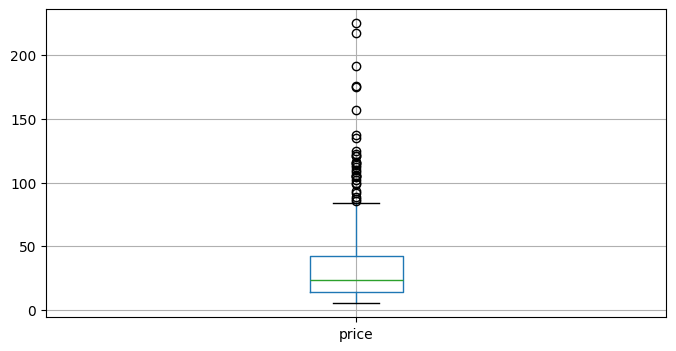

In [45]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
df_merge.boxplot(column="price", figsize=(8, 4))


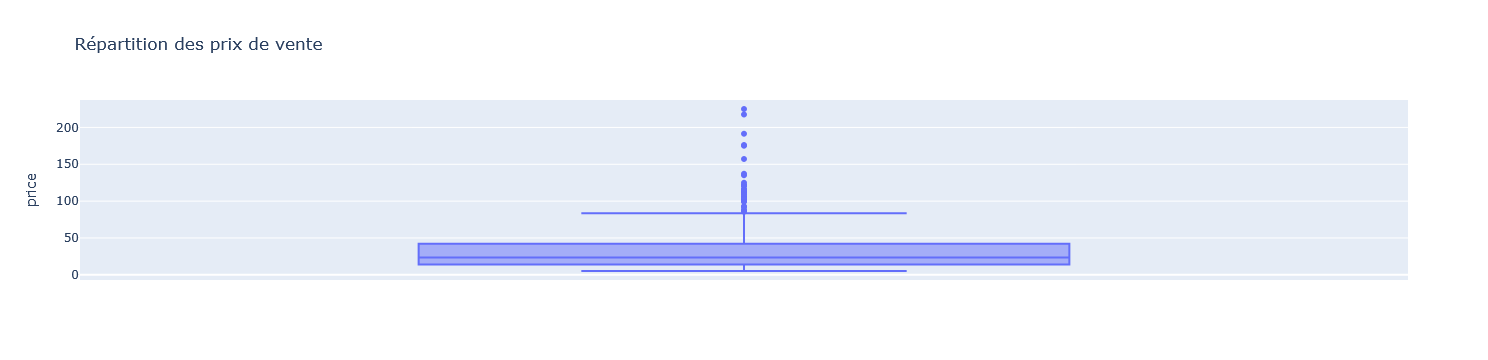

In [46]:
#Autre méthode avec plotly express
fig = px.box(df_merge, y="price", points="outliers", title="Répartition des prix de vente")
fig.show()


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

Le Z-score mesure à combien d’écarts-types une valeur se situe de la moyenne. 
Formule : Z = (x-μ)/σ

x = le prix     
μ= la moyenne      
σ = l'écart type

Si Z est supérieur à 3, la valeur est considérée comme atypique (outlyer).


EN BREF  : 

Le Z-score permet d’identifier les valeurs atypiques en mesurant la distance entre une valeur et la moyenne en nombre d’écarts-types.

Un Z-score supérieur à 3 signifie que le prix est situé à plus de trois écarts-types au-dessus de la moyenne et peut donc être considéré comme une valeur atypique.

In [47]:
#Calculer la moyenne du prix
moyenne_prix = df_merge["price"].mean()

#Calculer l'écart-type du prix
ecart_type_prix = df_merge["price"].std()

#Calculer le Z-score
df_merge["z_score"] = (df_merge["price"] - moyenne_prix) / ecart_type_prix


print("La moyenne des prix est de {:.2f} euro(s).".format(moyenne_prix))
print("L'écart-type des prix est de {:.2f}.".format(ecart_type_prix))

# Afficher les premières lignes
df_merge[["price","z_score"]].head()


La moyenne des prix est de 32.33 euro(s).
L'écart-type des prix est de 27.60.


,price,z_score
0,24.2,-0.294738
1,34.3,0.071253
2,20.8,-0.417943
3,14.1,-0.660729
4,46.0,0.495222


In [48]:
outliers_zscore = df_merge[df_merge["z_score"] > 3]

print("Nombre d'articles avec un z-score supérieur à 3 : {}".format(outliers_zscore.shape[0]))

display(outliers_zscore[["product_id", "post_title", "price", "z_score"]].sort_values(by="price", ascending=False))

Nombre d'articles avec un z-score supérieur à 3 : 13


,product_id,post_title,price,z_score
199,4352,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.0,6.981591
426,5001,David Duband Charmes-Chambertin Grand Cru 2014,217.5,6.709816
587,5892,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,191.3,5.760415
218,4402,Cognac Frapin VIP XO,176.0,5.205993
553,5767,Camille Giroud Clos de Vougeot 2016,175.0,5.169756
221,4406,Cognac Frapin Château de Fontpinot 1989 20 Ans...,157.0,4.517496
381,4904,Domaine Des Croix Corton Charlemagne Grand Cru...,137.0,3.792762
642,6126,Champagne Gosset Célébris Vintage 2007,135.0,3.720288
511,5612,Domaine Weinbach Gewurztraminer Grand Cru Furs...,124.8,3.350674
603,5917,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,122.0,3.249211


In [49]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
seuil_z3 = moyenne_prix + 3 * ecart_type_prix
print("Seuil de prix pour un Z-score supérieur à 3 :", seuil_z3)

Seuil de prix pour un Z-score supérieur à 3 : 115.12268073098096


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [50]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
display(df_merge["price"].describe())


count    714.000000
mean      32.333683
std       27.596332
min        5.200000
25%       14.062500
50%       23.450000
75%       42.075000
max      225.000000
Name: price, dtype: float64

In [51]:
#Définir un seuil pour les articles "outliers" en prix
q1 = df_merge["price"].quantile(0.25)
q3 = df_merge["price"].quantile(0.75)
iqr = q3 - q1
seuil_superieur = q3 + 1.5 * iqr
print("Le seuil supérieur des outliers de prix est de {:.2f} euro(s).".format(seuil_superieur))


Le seuil supérieur des outliers de prix est de 84.09 euro(s).


In [52]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
outliers_iqr = df_merge[df_merge["price"] > seuil_superieur].sort_values(by="price", ascending=False)
nb_outliers = outliers_iqr.shape[0]
proportion_outliers = nb_outliers / df_merge.shape[0]
print("Nombre d'articles outliers : {}".format(nb_outliers))
print("Proportion d'articles outliers : {:.2%}".format(proportion_outliers))
display(outliers_iqr[["product_id", "post_title", "product_type", "price"]])


Nombre d'articles outliers : 31
Proportion d'articles outliers : 4.34%


,product_id,post_title,product_type,price
199,4352,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Champagne,225.0
426,5001,David Duband Charmes-Chambertin Grand Cru 2014,Vin,217.5
587,5892,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Champagne,191.3
218,4402,Cognac Frapin VIP XO,Cognac,176.0
553,5767,Camille Giroud Clos de Vougeot 2016,Vin,175.0
221,4406,Cognac Frapin Château de Fontpinot 1989 20 Ans...,Cognac,157.0
381,4904,Domaine Des Croix Corton Charlemagne Grand Cru...,Vin,137.0
642,6126,Champagne Gosset Célébris Vintage 2007,Champagne,135.0
511,5612,Domaine Weinbach Gewurztraminer Grand Cru Furs...,Vin,124.8
603,5917,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,Whisky,122.0


In [53]:
#Selon vous, ces outliers sont-ils justifiés à Comment le démontrer si cela est possible ?
print("Les outliers semblent justifiés : il s'agit principalement de champagnes, cognacs, whiskies et grands crus à forte valeur unitaire.")
print("On peut le démontrer en consultant leur intitulé produit, leur type de produit et leur présence parmi les références premium du catalogue.")


Les outliers semblent justifiés : il s'agit principalement de champagnes, cognacs, whiskies et grands crus à forte valeur unitaire.
On peut le démontrer en consultant leur intitulé produit, leur type de produit et leur présence parmi les références premium du catalogue.


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [54]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article
df_merge["ca_par_article"] = df_merge["price"] * df_merge["total_sales"]

#Calculer la somme de la colonne "ca_par_article"
#Ce résultat correspond au chiffre d'affaire du site web
ca_total = df_merge["ca_par_article"].sum()
print("Le chiffre d'affaires total du site web est de {:.2f} euro(s).".format(ca_total))


Le chiffre d'affaires total du site web est de 143680.10 euro(s).


,post_title,product_type,total_sales,price,ca_par_article
0,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Champagne,11.0,225.0,2475.0
1,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Champagne,6.0,191.3,1147.8
2,Champagne Egly-Ouriet Grand Cru Brut Rosé,Champagne,14.0,79.5,1113.0
3,Agnès Levet Côte Rôtie Améthyste 2017,Vin,20.0,41.2,824.0
4,Domaine des Comtes Lafon Volnay 1er Cru Santen...,Vin,7.0,115.0,805.0
5,Champagne Agrapart &amp; Fils Minéral Extra Br...,Champagne,9.0,86.8,781.2
6,Domaine des Comtes Lafon Volnay 1er Cru Santen...,Vin,7.0,105.0,735.0
7,Camille Giroud Clos de Vougeot 2016,Vin,4.0,175.0,700.0
8,Champagne Gosset Célébris Vintage 2007,Champagne,5.0,135.0,675.0
9,Champagne Agrapart &amp; Fils L'Avizoise Extra...,Champagne,6.0,112.0,672.0


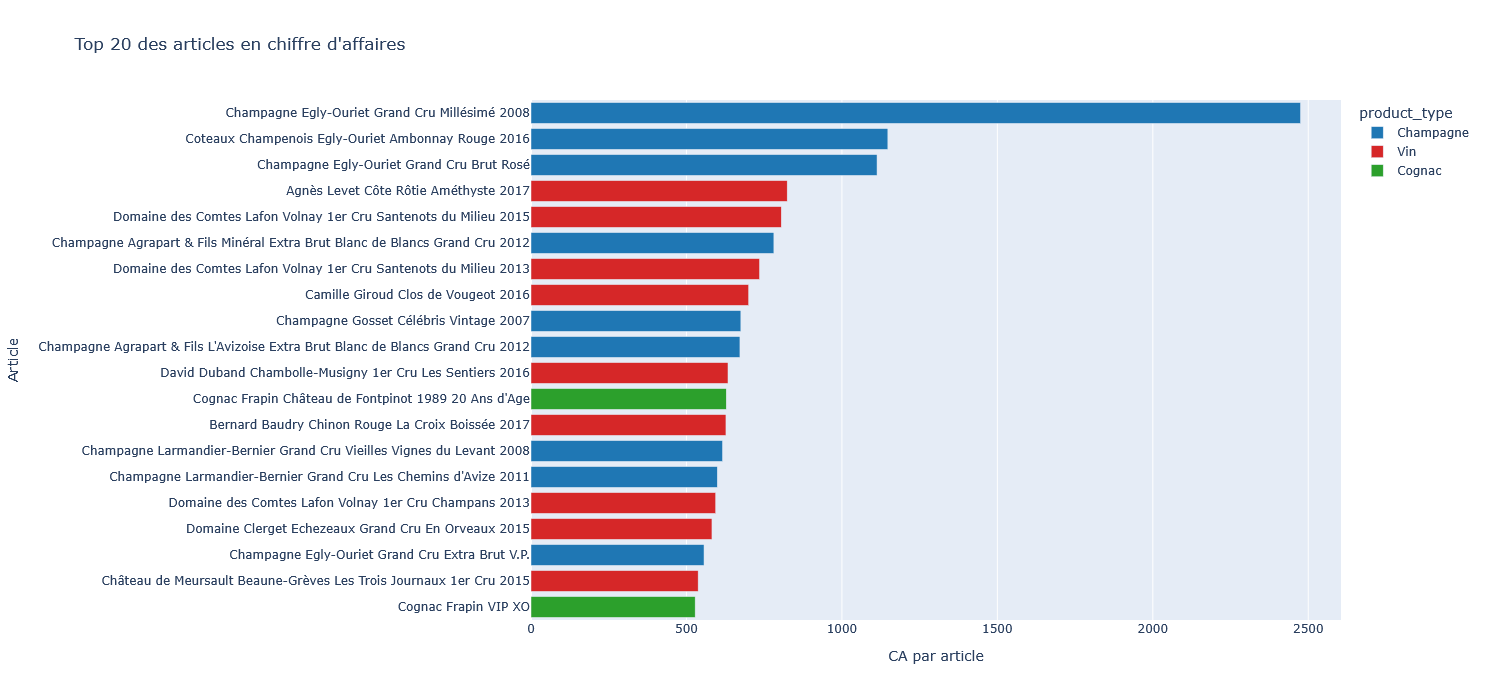

In [55]:
###############################
# Palmarès des articles en CA #
###############################

# Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_ca = df_merge.sort_values(by="ca_par_article", ascending=False)

# Réinitialiser l'index du dataset par un reset_index
df_ca = df_ca.reset_index(drop=True)

# Afficher les 20 premiers articles en CA
display(df_ca[["post_title", "product_type", "total_sales", "price", "ca_par_article"]].head(20))

# Graphique en barre horizontal des 20 premiers articles avec plotly express
df_ca_top20 = df_ca.head(20).sort_values(by="ca_par_article", ascending=False)

couleurs_types = {
    "Champagne": "#1f77b4",
    "Vin": "#d62728",
    "Cognac": "#2ca02c",
    "Whisky": "#ff7f0e",
    "Gin": "#9467bd",
    "Huile d'olive": "#8c564b",
    "Autre": "#7f7f7f"
}

fig = px.bar(
    df_ca_top20,
    x="ca_par_article",
    y="post_title",
    color="product_type",
    color_discrete_map=couleurs_types,
    orientation="h",
    title="Top 20 des articles en chiffre d'affaires",
    category_orders={
        "post_title": df_ca_top20["post_title"].tolist()
    }
)

fig.update_layout(
    xaxis_title="CA par article",
    yaxis_title="Article",
    height=700
)

fig.show()



In [56]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_ca["part_ca"] = df_ca["ca_par_article"] / df_ca["ca_par_article"].sum()

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_ca["part_ca_cumulee"] = df_ca["part_ca"].cumsum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
nb_articles_80_ca = (df_ca["part_ca_cumulee"] <= 0.80).sum() + 1

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
print("{} articles représentent 80% du CA, soit {:.2%} du catalogue.".format(nb_articles_80_ca, nb_articles_80_ca / df_ca.shape[0]))


435 articles représentent 80% du CA, soit 60.92% du catalogue.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

,post_title,product_type,total_sales,price
0,Château De La Selve IGP Coteaux de l'Ardèche M...,Vin,36.0,9.9
1,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,Vin,27.0,9.9
2,I Fabbri Chianti Classico Lamole 2017,Vin,24.0,14.9
3,Bernard Baudry Chinon Rouge La Croix Boissée 2017,Vin,22.0,28.5
4,François Baur Pinot Noir Schlittweg 2017,Vin,22.0,12.7
5,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,Vin,20.0,5.2
6,Agnès Levet Côte Rôtie Améthyste 2017,Vin,20.0,41.2
7,Xavier Frissant Touraine Amboise Chenin Les Pi...,Vin,18.0,11.6
8,Maurel Pays d'Oc Merlot 2018,Vin,17.0,5.8
9,Château Tour Haut-Caussan Médoc 2015,Vin,17.0,17.1


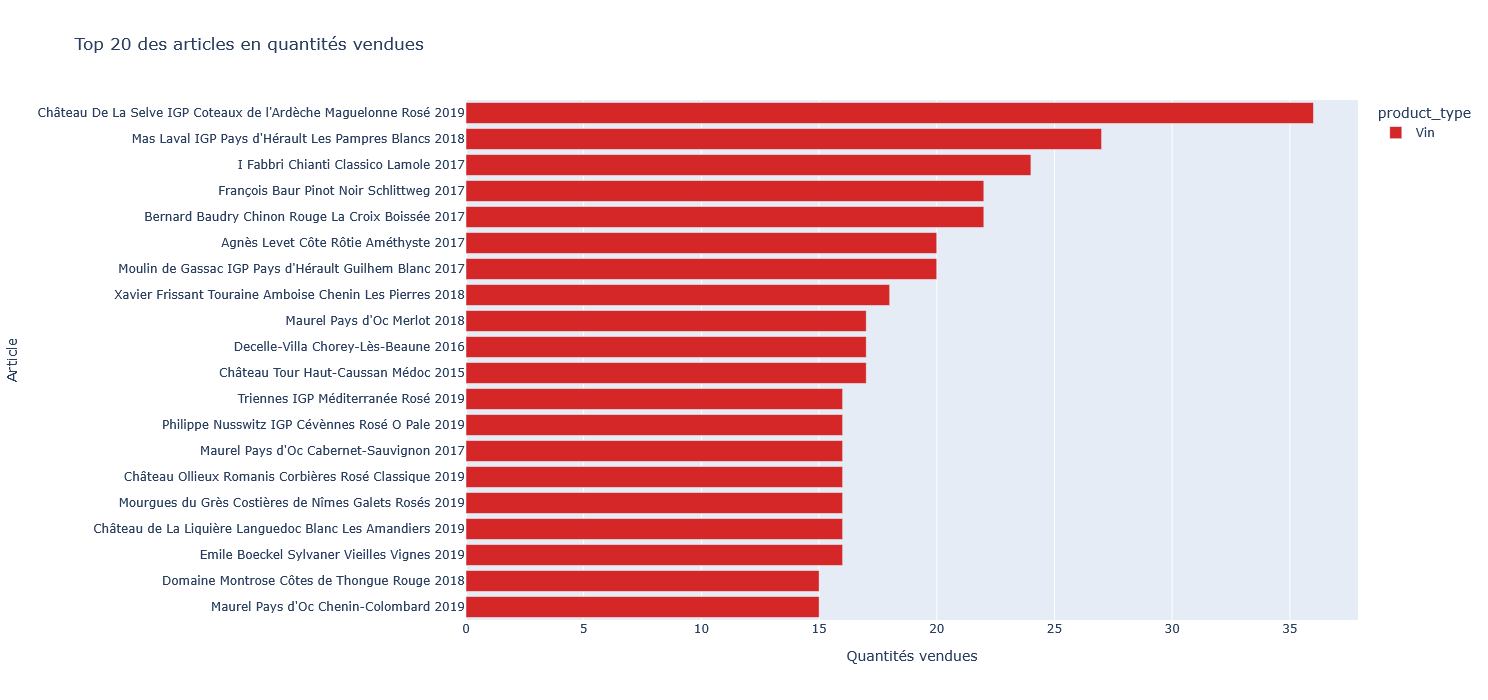

In [57]:
#####################################
# Palmarès des articles en quantité #
#####################################

# Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_quantites = df_merge.sort_values(by="total_sales", ascending=False)

# Réinitialiser l'index du dataset par un reset_index
df_quantites = df_quantites.reset_index(drop=True)

# Afficher les 20 premiers articles en quantité
display(df_quantites[["post_title", "product_type", "total_sales", "price"]].head(20))

# Préparer le top 20 pour un affichage horizontal
df_quantites_top20 = df_quantites.head(20).sort_values(by="total_sales", ascending=True)

# Graphique en barre horizontal des 20 premiers articles avec plotly express
fig = px.bar(
    df_quantites_top20,
    x="total_sales",
    y="post_title",
    color="product_type",
    color_discrete_map=couleurs_types,
    orientation="h",
    title="Top 20 des articles en quantités vendues"
)

fig.update_yaxes(
    categoryorder="array",
    categoryarray=df_quantites_top20["post_title"].tolist()
)

fig.update_layout(
    xaxis_title="Quantités vendues",
    yaxis_title="Article",
    height=700
)

fig.show()


In [58]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_quantites["part_quantite"] = df_quantites["total_sales"] / df_quantites["total_sales"].sum()

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_quantites["part_quantite_cumulee"] = df_quantites["part_quantite"].cumsum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
nb_articles_80_quantite = (df_quantites["part_quantite_cumulee"] <= 0.80).sum() + 1

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
print("{} articles représentent 80% des ventes en quantité, soit {:.2%} du catalogue.".format(nb_articles_80_quantite, nb_articles_80_quantite / df_quantites.shape[0]))


434 articles représentent 80% des ventes en quantité, soit 60.78% du catalogue.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

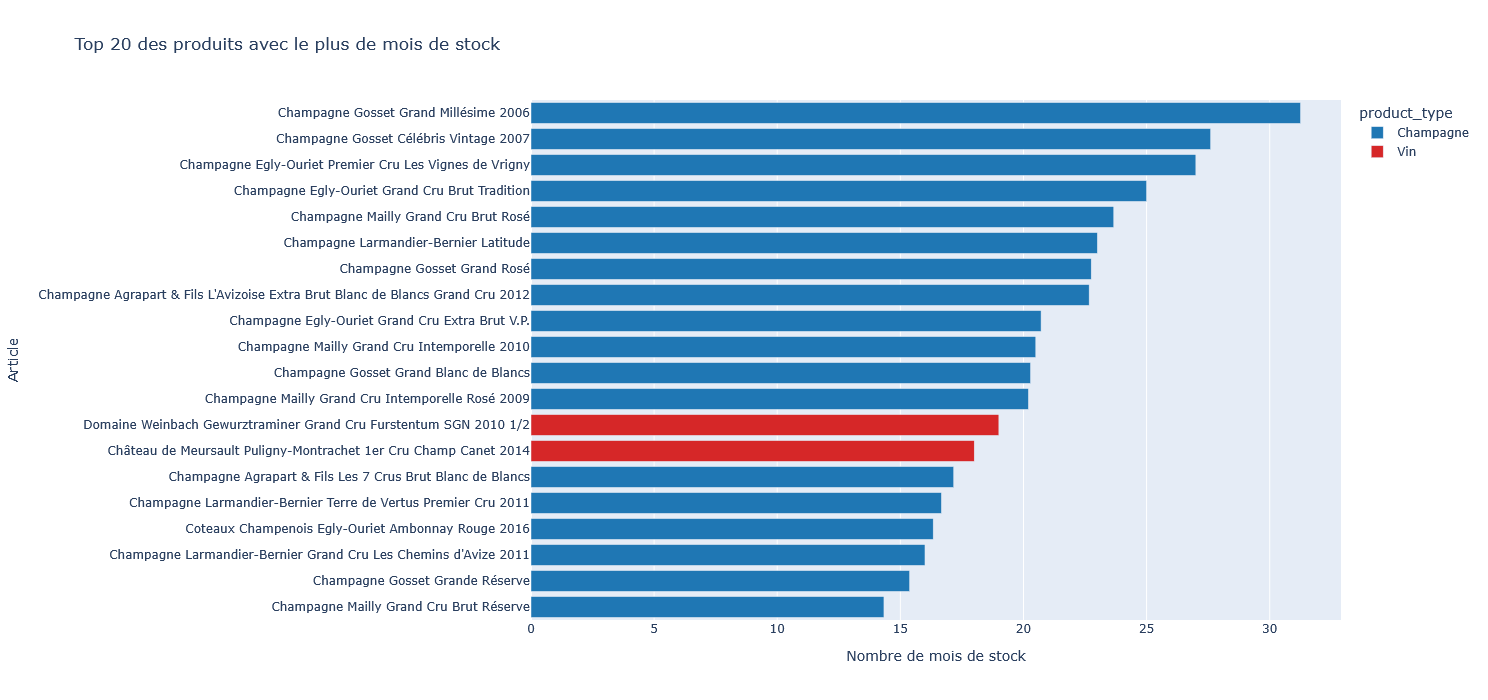

In [59]:
######################################
# Calculer le nombre de mois de stock #
######################################

# Création de la colonne Rotation de stock
df_merge["mois_de_stock"] = np.where(
    df_merge["total_sales"] > 0,
    df_merge["stock_quantity"] / df_merge["total_sales"],
    0
)

# Remplacement des "inf" par 0
df_merge["mois_de_stock"] = df_merge["mois_de_stock"].replace([np.inf, -np.inf], 0)

# Effectuer le tri dans l'ordre décroissant du nombre de mois de stock
df_stock = df_merge.sort_values(by="mois_de_stock", ascending=False)

# Préparer le top 20 pour un affichage horizontal
df_stock_top20 = df_stock.head(20).sort_values(by="mois_de_stock", ascending=True)

# Graphique en barre horizontal du top 20 des produits qui ont le plus de mois de stock
fig = px.bar(
    df_stock_top20,
    x="mois_de_stock",
    y="post_title",
    color="product_type",
    color_discrete_map=couleurs_types,
    orientation="h",
    title="Top 20 des produits avec le plus de mois de stock"
)

fig.update_yaxes(
    categoryorder="array",
    categoryarray=df_stock_top20["post_title"].tolist()
)

fig.update_layout(
    xaxis_title="Nombre de mois de stock",
    yaxis_title="Article",
    height=700
)

fig.show()


In [60]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_merge["valorisation_stock_euros"] = df_merge["stock_quantity"] * df_merge["purchase_price"]

#Calculer la somme de la colonne "Valorisation_stock_euros"
print("La valorisation totale du stock est de {:.2f} euro(s).".format(df_merge["valorisation_stock_euros"].sum()))


La valorisation totale du stock est de 277305.77 euro(s).


In [61]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
print("Le nombre total d'unités en stock est de {}.".format(df_merge["stock_quantity"].sum()))


Le nombre total d'unités en stock est de 16739.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [62]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT
df_merge["prix_ht"] = df_merge["price"] / 1.20
df_merge["prix_achat_ht"] = df_merge["purchase_price"] / 1.20


#Création de la colonne Taux de marge
df_merge["taux_marge"] = ((df_merge["prix_ht"] - df_merge["prix_achat_ht"]) / df_merge["prix_achat_ht"])

#Afficher le prix minimum de la colonne "taux_marge"
print("Le taux de marge minimum est de {:.2f}%".format(df_merge["taux_marge"].min()))

#Afficher le prix maximum de la colonne "taux_marge"
print("Le taux de marge maximum est de {:.2f}%".format(df_merge["taux_marge"].max()))


Le taux de marge minimum est de -0.84%
Le taux de marge maximum est de 1.30%


In [63]:
#Affichage de la ligne avec un taux de marge inférieur à 0
display(df_merge[df_merge["taux_marge"] < 0][["product_id", "post_title", "price", "purchase_price", "prix_ht", "taux_marge"]])


,product_id,post_title,price,purchase_price,prix_ht,taux_marge
201,4355,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,12.65,77.48,10.541667,-0.836732


In [64]:
#Création d'un dataframe avec les taux positifs
df_marge_positive = df_merge[df_merge["taux_marge"] >= 0].copy()

#Afficher le prix minimum de la colonne "taux_marge"
print("Le taux de marge minimum positif est de {:.2f}%".format(df_marge_positive["taux_marge"].min()))

#Afficher le prix maximum de la colonne "taux_marge"
print("Le taux de marge maximum positif est de {:.2f}%".format(df_marge_positive["taux_marge"].max()))


Le taux de marge minimum positif est de 0.55%
Le taux de marge maximum positif est de 1.30%


,product_type,taux_marge,taux_marge_pct
1,Cognac,1.187794,118.779435
5,Whisky,1.180870,118.087005
2,Gin,1.097902,109.790210
4,Vin,0.937953,93.795313
6,NaN,0.879699,87.969925
0,Champagne,0.679455,67.945545
3,Huile d'olive,0.600682,60.068162


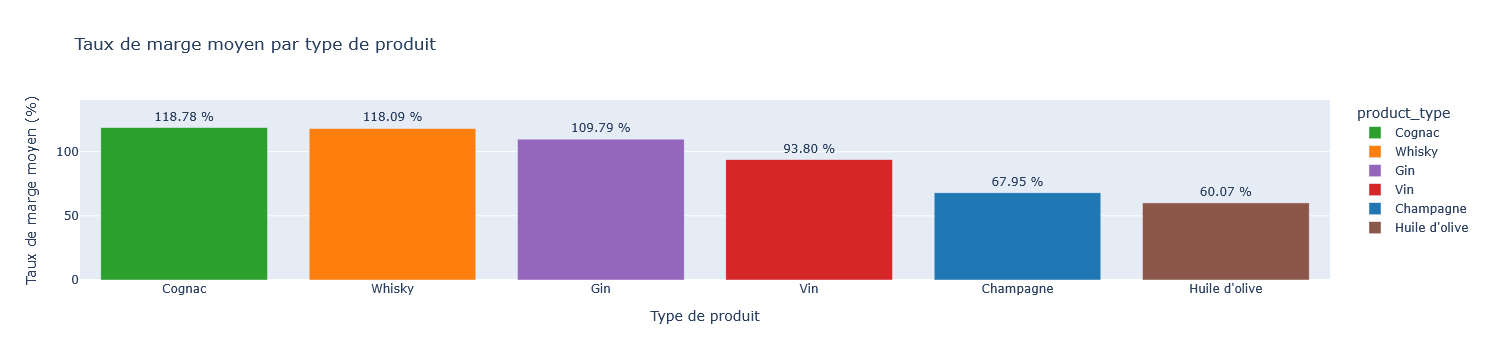

In [65]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
df_taux_marge_type = df_marge_positive.groupby("product_type", dropna=False)["taux_marge"].mean().reset_index().sort_values(by="taux_marge", ascending=False)
df_taux_marge_type["taux_marge_pct"] = df_taux_marge_type["taux_marge"] * 100
display(df_taux_marge_type)

# Affichage dans un graphique du taux de marge par type de produit
fig = px.bar(
    df_taux_marge_type,
    x="product_type",
    y="taux_marge_pct",
    text="taux_marge_pct",
    title="Taux de marge moyen par type de produit",
    color="product_type",
    color_discrete_map=couleurs_types
)

fig.update_traces(
    texttemplate="%{text:.2f} %",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Type de produit",
    yaxis_title="Taux de marge moyen (%)"
)

fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

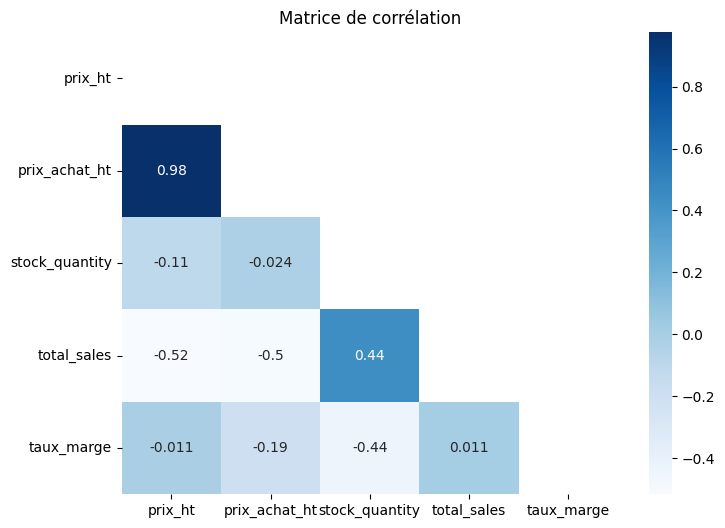

In [66]:
############################
# Analyse des corrélations #
############################

#Importation de Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

#Création d'une heatmap de corrélation avec les variables stock, sales et price
#On peut également créer un mask pour n'afficher qu'une demi heatmap
colonnes_corr = ["prix_ht", "prix_achat_ht", "stock_quantity", "total_sales", "taux_marge"]
matrice_corr = df_merge[colonnes_corr].corr()
mask = np.triu(np.ones_like(matrice_corr, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(matrice_corr, annot=True, cmap="Blues", mask=mask)
plt.title("Matrice de corrélation")
plt.show()


In [67]:
#Que peut-on conclure des corrélations ?
print("Le prix de vente est très fortement corrélé au prix d'achat, ce qui est logique d'un point de vue commercial.")
print("Les ventes sont modérément et négativement corrélées au prix : les articles les plus chers se vendent globalement en plus faibles quantités.")
print("Le stock est modérément et positivement corrélé aux ventes, ce qui suggère un approvisionnement plus important sur les références les plus demandées.")


Le prix de vente est très fortement corrélé au prix d'achat, ce qui est logique d'un point de vue commercial.
Les ventes sont modérément et négativement corrélées au prix : les articles les plus chers se vendent globalement en plus faibles quantités.
Le stock est modérément et positivement corrélé aux ventes, ce qui suggère un approvisionnement plus important sur les références les plus demandées.


In [68]:
df_merge["valorisation_stock"] = df_merge["stock_quantity"] * df_merge["purchase_price"]
df_merge["valorisation_stock_vente"] = df_merge["stock_quantity"] * df_merge["price"]

print("Le stock total est de {} unités.".format(df_merge["stock_quantity"].sum()))
print("La valorisation d'achat du stock est de {:.2f} euros.".format(df_merge["valorisation_stock"].sum()))
print("La valeur potentielle du stock au prix de vente est de {:.2f} euros.".format(df_merge["valorisation_stock_vente"].sum()))
print("Pourcentage de marge possible: {:.2f}%.".format((df_merge["valorisation_stock_vente"].sum() / df_merge["valorisation_stock"].sum())*100))

print("Soit : {:.2f} euros.".format(df_merge["valorisation_stock_vente"].sum() - df_merge["valorisation_stock"].sum()))

Le stock total est de 16739 unités.
La valorisation d'achat du stock est de 277305.77 euros.
La valeur potentielle du stock au prix de vente est de 494593.40 euros.
Pourcentage de marge possible: 178.36%.
Soit : 217287.63 euros.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [69]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.  
chemin_export = racine_projet / "df_merge_bottleneck.xlsx"
df_merge.to_excel(chemin_export, index=False)
print("Le fichier a été exporté vers : {}".format(chemin_export))


Le fichier a été exporté vers : D:\openclassroom\P13\mission_1\amélioration_P6\df_merge_bottleneck.xlsx


# P13 — Segmentation du portefeuille produits

Cette amélioration suit une démarche de clustering fondée sur la standardisation, l'ACP, la lecture hiérarchique, le choix argumenté de `k`, puis le profilage métier des groupes. L'unité d'analyse est ici une **référence produit**.

> Les ventes de la base sont cumulées et non datées. Cette analyse aide à prioriser le portefeuille ; elle ne produit ni prévision de demande ni calendrier saisonnier.

In [70]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
DATA_PATH = Path('df_merge_bottleneck.xlsx')
df = pd.read_excel(DATA_PATH)
FEATURES = ['prix_ht', 'taux_marge', 'stock_quantity', 'total_sales']
df[FEATURES].info()

<class 'pandas.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   prix_ht         714 non-null    float64
 1   taux_marge      714 non-null    float64
 2   stock_quantity  714 non-null    int64  
 3   total_sales     714 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 22.4 KB


## 6. Préparation des variables de segmentation

Le modèle n'utilise que quatre variables non redondantes : prix HT, taux de marge, stock et ventes cumulées. Les deux variables de volume sont transformées avec `log1p` pour limiter l'effet des très fortes valeurs ; les quatre variables sont ensuite standardisées. Le chiffre d'affaires et la valorisation du stock servent au **profilage**, pas à construire les groupes, afin d'éviter de compter deux fois les mêmes phénomènes.

In [71]:
X = df[FEATURES].copy()
for col in ['stock_quantity', 'total_sales']:
    X[col] = np.log1p(X[col].clip(lower=0))

print('Valeurs manquantes :')
display(X.isna().sum().to_frame('nb_manquants'))
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pd.DataFrame(X_scaled, columns=FEATURES).describe().round(2)

Valeurs manquantes :


,nb_manquants
prix_ht,0
taux_marge,0
stock_quantity,0
total_sales,0


,prix_ht,taux_marge,stock_quantity,total_sales
count,714.00,714.00,714.00,714.00
mean,0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00
min,-0.98,-15.33,-2.69,-3.42
25%,-0.66,-0.46,-0.47,-0.45
50%,-0.32,0.03,0.24,0.22
75%,0.35,0.55,0.62,0.70
max,6.99,3.16,2.12,2.57


## 7. ACP — réduction et lecture des axes

L'ACP est utilisée pour résumer les variables et visualiser les références. Elle constitue un essai méthodologique : le clustering final sera réalisé directement sur les quatre variables métier préparées et standardisées.

Composantes retenues : 3
Variance expliquée cumulée : 93.7%


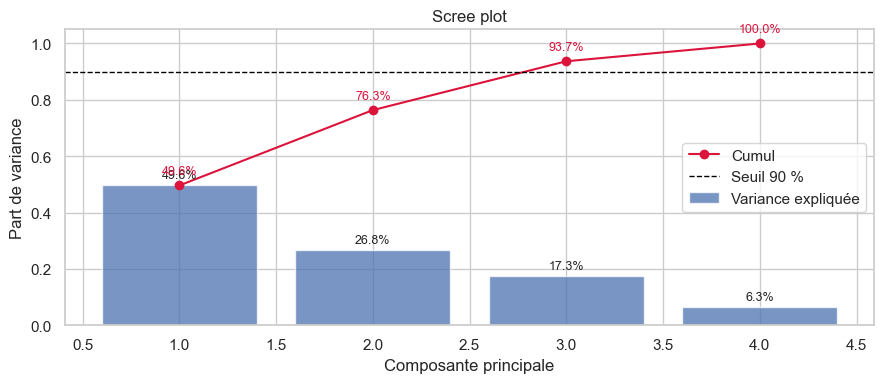

,PC1,PC2,PC3
prix_ht,-0.471,-0.313,0.801
taux_marge,-0.125,0.906,0.336
stock_quantity,0.601,-0.232,0.419
total_sales,0.633,0.166,0.264


In [72]:
pca_full = PCA().fit(X_scaled)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)
n_components = int(np.argmax(cumulative >= 0.90) + 1)
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Composantes retenues : {n_components}')
print(f'Variance expliquée cumulée : {pca.explained_variance_ratio_.sum():.1%}')
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(range(1, len(explained) + 1), explained, alpha=.75, label='Variance expliquée')
ax.bar_label(bars, labels=[f'{value:.1%}' for value in explained], padding=3, fontsize=9)
ax.plot(range(1, len(explained) + 1), cumulative, marker='o', color='crimson', label='Cumul')
for component, value in enumerate(cumulative, start=1):
    ax.annotate(f'{value:.1%}', (component, value), textcoords='offset points', xytext=(0, 8), ha='center', color='crimson', fontsize=9)
ax.axhline(.90, color='black', linestyle='--', linewidth=1, label='Seuil 90 %')
ax.set(xlabel='Composante principale', ylabel='Part de variance', title='Scree plot')
ax.legend(); plt.tight_layout(); plt.show()

loadings = pd.DataFrame(pca.components_.T, index=FEATURES, columns=[f'PC{i}' for i in range(1, n_components + 1)])
display(loadings.round(3))

## 8. Choix du nombre de clusters : CAH puis K-means

Le dendrogramme de Ward donne une lecture structurelle des rapprochements. Puis plusieurs partitions K-means sont comparées avec la silhouette, l'inertie et la taille des groupes. La meilleure silhouette seule ne décide pas tout : une segmentation à quatre groupes est retenue si elle est suffisamment cohérente et apporte une action métier distincte.

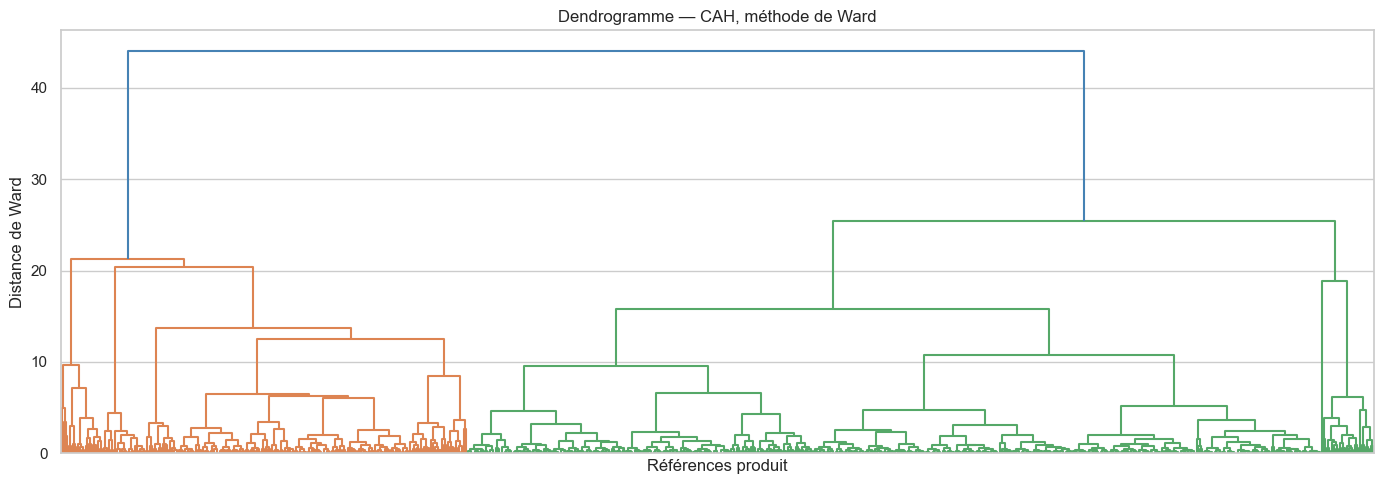

,k,silhouette,inertie,taille_min,taille_max
0,2,0.437,1843.536,225,489
1,3,0.461,1513.790,30,465
2,4,0.447,1277.143,30,449
3,5,0.425,1070.286,24,409
4,6,0.430,892.865,1,409
5,7,0.303,790.669,1,230


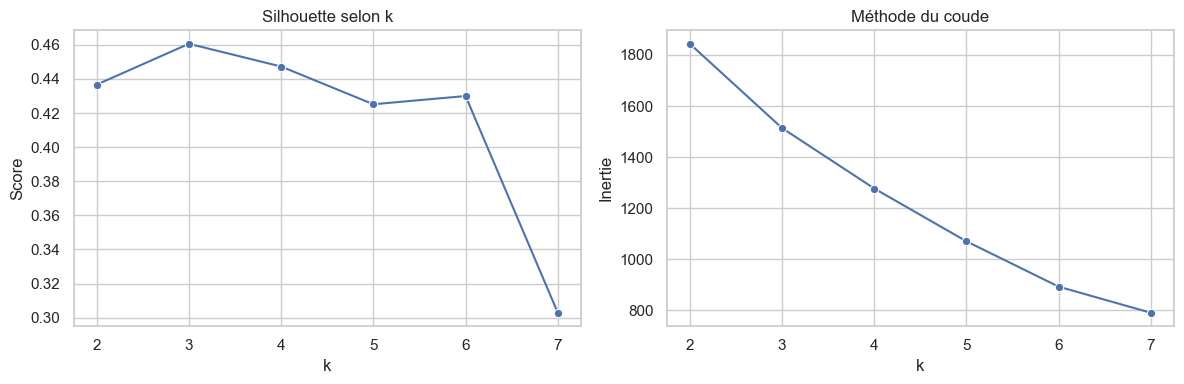

In [73]:
Z = linkage(X_scaled, method='ward')
fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, no_labels=True, color_threshold=None, above_threshold_color='steelblue', ax=ax)
ax.set(title='Dendrogramme — CAH, méthode de Ward', xlabel='Références produit', ylabel='Distance de Ward')
plt.tight_layout(); plt.show()

scores = []
for k in range(2, 8):
    model = KMeans(n_clusters=k, random_state=42, n_init=30)
    labels = model.fit_predict(X_scaled)
    sizes = pd.Series(labels).value_counts()
    scores.append({'k': k, 'silhouette': silhouette_score(X_scaled, labels),
                   'inertie': model.inertia_, 'taille_min': sizes.min(), 'taille_max': sizes.max()})
scores_df = pd.DataFrame(scores)
display(scores_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=scores_df, x='k', y='silhouette', marker='o', ax=axes[0])
axes[0].set(title='Silhouette selon k', ylabel='Score')
sns.lineplot(data=scores_df, x='k', y='inertie', marker='o', ax=axes[1])
axes[1].set(title='Méthode du coude', ylabel='Inertie')
plt.tight_layout(); plt.show()

### Analyse des plus longs sauts de fusion

Le tableau ci-dessous matérialise les derniers sauts de distance du dendrogramme. Un saut élevé indique qu'on force ensuite le rapprochement de groupes relativement éloignés ; il sert de repère complémentaire pour choisir la coupure.

In [74]:
# Dernières fusions de la CAH : tableau des sauts de distance
distances = Z[-7:, 2]
rows = []
previous_distance = distances[0]
# Les sept dernières fusions font passer de 8 groupes à 1 groupe.
current_clusters = len(distances) + 1

for distance in distances[1:]:
    jump = distance - previous_distance
    rows.append({
        'Fusion': f'{current_clusters} clusters → {current_clusters - 1}',
        'Distance': round(distance, 2),
        'Saut_val': round(jump, 2),
    })
    current_clusters -= 1
    previous_distance = distance

jump_df = pd.DataFrame(rows)
max_jump = jump_df['Saut_val'].max()
jump_df['Saut'] = jump_df['Saut_val'].apply(
    lambda value: f'+{value:.2f} → plus grand saut' if value == max_jump else f'+{value:.2f}'
)
jump_df[['Fusion', 'Distance', 'Saut']]

,Fusion,Distance,Saut
0,8 clusters → 7,15.75,+1.99
1,7 clusters → 6,18.84,+3.09
2,6 clusters → 5,20.38,+1.54
3,5 clusters → 4,21.31,+0.93
4,4 clusters → 3,25.39,+4.08
5,3 clusters → 2,44.09,+18.69 → plus grand saut


### Contrôle — ACP ou variables standardisées ?

L'ACP est utile pour visualiser et réduire la redondance, mais elle n'est pas indispensable avec seulement quatre variables. On compare donc K-means sur les trois axes ACP et sur les quatre variables standardisées d'origine. Des résultats voisins indiquent que la segmentation ne dépend pas artificiellement de la réduction de dimension.

,représentation,k,silhouette,inertie,taille_min,taille_max
0,Axes ACP (3 composantes),3,0.475,1342.165,32,466
1,Axes ACP (3 composantes),4,0.444,1123.330,31,439
2,Variables standardisées (4 variables),3,0.461,1513.790,30,465
3,Variables standardisées (4 variables),4,0.447,1277.143,30,449


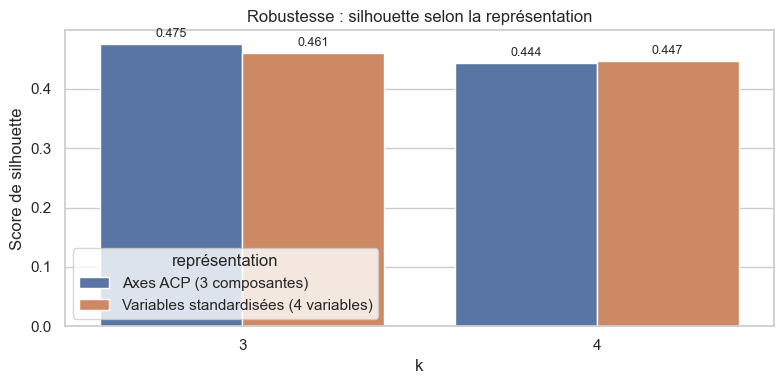

In [75]:
robustness_rows = []
for representation, data in [('Axes ACP (3 composantes)', X_pca), ('Variables standardisées (4 variables)', X_scaled)]:
    for k in [3, 4]:
        model = KMeans(n_clusters=k, random_state=42, n_init=30)
        labels = model.fit_predict(data)
        sizes = pd.Series(labels).value_counts()
        robustness_rows.append({
            'représentation': representation, 'k': k,
            'silhouette': silhouette_score(data, labels),
            'inertie': model.inertia_,
            'taille_min': sizes.min(), 'taille_max': sizes.max(),
        })
robustness_df = pd.DataFrame(robustness_rows)
display(robustness_df.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=robustness_df, x='k', y='silhouette', hue='représentation', ax=ax)
ax.set(title='Robustesse : silhouette selon la représentation', ylabel='Score de silhouette')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout(); plt.show()

### Comparaison métier — K=3 et K=4

Les deux solutions sont conservées pour lecture. `K=3` est celle privilégiée par les critères statistiques ; `K=4` est une lecture plus fine qui peut isoler les références inactives. Les tableaux et projections permettent de vérifier si ce quatrième groupe est utile aux équipes, ou s'il ne fait que fragmenter un groupe existant.

In [76]:
# Cellule fusionnée avec la comparaison K=3 / K=4 suivante.
# La cellule suivante conserve le tableau de profils et la projection ACP des clusters directs.

=== K=3 — silhouette : 0.461 ===


,references,prix_median,marge_moyenne,stock_median,ventes_mediane,ca_total,valorisation_stock
cluster,,,,,,,
0,465,14.25,0.94,26.0,10.0,84450.35,109268.95
1,30,42.12,0.62,101.0,6.0,10951.30,123583.70
2,219,41.67,0.96,6.0,4.0,48278.45,44453.12


=== K=4 — silhouette : 0.447 ===


,references,prix_median,marge_moyenne,stock_median,ventes_mediane,ca_total,valorisation_stock
cluster,,,,,,,
0,449,14.08,0.94,26.0,10.0,79299.05,105424.34
1,203,41.25,0.96,7.0,4.0,52778.65,47672.64
2,30,42.12,0.62,101.0,6.0,10951.30,123583.70
3,32,32.29,0.96,0.0,0.0,651.10,625.09


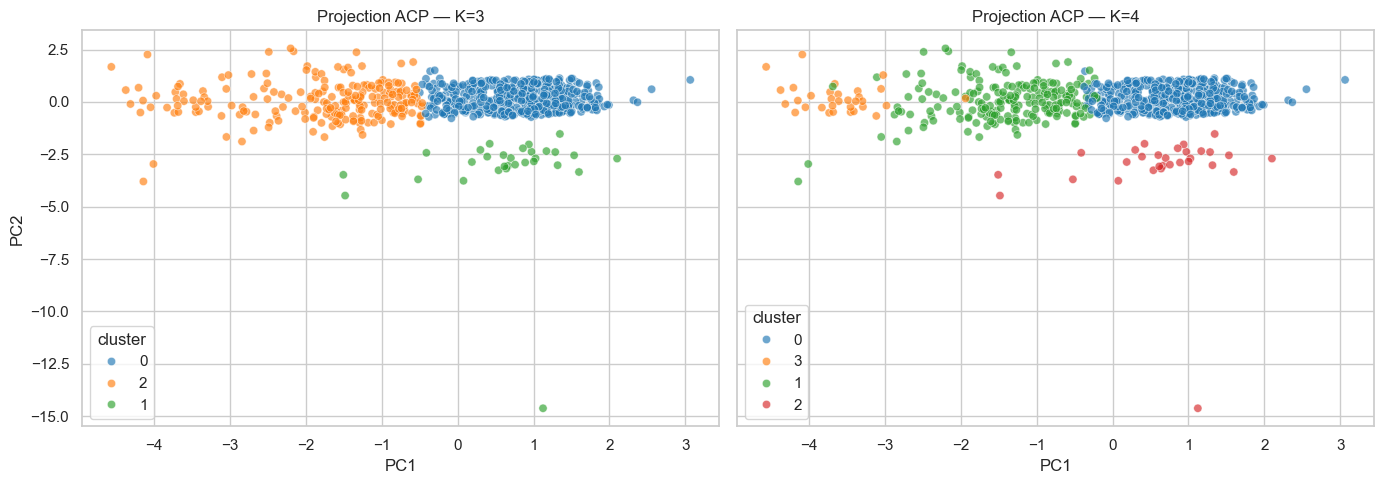

In [77]:
PROFILE_COLUMNS = {
    'references': ('product_id', 'size'),
    'prix_median': ('prix_ht', 'median'),
    'marge_moyenne': ('taux_marge', 'mean'),
    'stock_median': ('stock_quantity', 'median'),
    'ventes_mediane': ('total_sales', 'median'),
    'ca_total': ('ca_par_article', 'sum'),
    'valorisation_stock': ('valorisation_stock', 'sum'),
}
comparison_profiles = {}
comparison_labels = {}
for k in [3, 4]:
    model = KMeans(n_clusters=k, random_state=42, n_init=30)
    labels = model.fit_predict(X_scaled)
    comparison_labels[k] = labels
    comparison_profiles[k] = (
        df.assign(cluster=labels).groupby('cluster').agg(**PROFILE_COLUMNS).round(2)
    )
    print(f'=== K={k} — silhouette : {silhouette_score(X_scaled, labels):.3f} ===')
    display(comparison_profiles[k])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
for ax, k in zip(axes, [3, 4]):
    plot_df = pd.DataFrame({'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1], 'cluster': comparison_labels[k].astype(str)})
    sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='cluster', palette='tab10', alpha=.65, ax=ax)
    ax.set_title(f'Projection ACP — K={k}')
plt.tight_layout(); plt.show()

### Décision de modélisation

Le modèle final utilise les **quatre variables standardisées directement**, sans ACP : elles sont peu nombreuses et restent toutes interprétables. L'ACP est conservée plus haut comme test méthodologique et support de visualisation.

La comparaison `K=3` / `K=4` est conservée. La solution **K=4** est retenue pour la restitution : elle isole un profil de références inactives, utile à l'audit catalogue, malgré un score de silhouette légèrement inférieur à `K=3`.

In [78]:
N_CLUSTERS = 4
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=30)
labels_kmeans = kmeans.fit_predict(X_scaled)
labels_cah = fcluster(Z, t=N_CLUSTERS, criterion='maxclust')
df['segment'] = labels_kmeans
print(f'Silhouette finale : {silhouette_score(X_scaled, labels_kmeans):.3f}')
print(f'Accord CAH / K-means (ARI) : {adjusted_rand_score(labels_cah, labels_kmeans + 1):.3f}')
display(pd.crosstab(labels_cah, labels_kmeans + 1))

Silhouette finale : 0.447
Accord CAH / K-means (ARI) : 0.754


col_0,1,2,3,4
row_0,,,,
1,0,22,1,0
2,11,155,0,32
3,438,26,0,0
4,0,0,29,0


## 9. Projection ACP et profils des segments

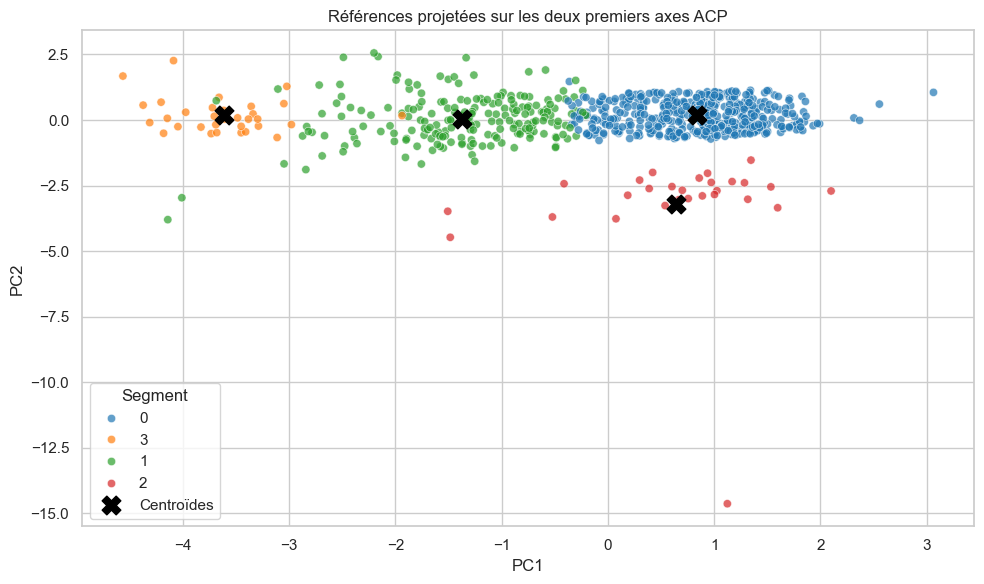

,references,prix_median,marge_moyenne,stock_median,ventes_mediane,ca_total,valorisation_stock
segment,,,,,,,
0,449,14.08,0.94,26.0,10.0,79299.05,105424.34
1,203,41.25,0.96,7.0,4.0,52778.65,47672.64
2,30,42.12,0.62,101.0,6.0,10951.30,123583.70
3,32,32.29,0.96,0.0,0.0,651.10,625.09


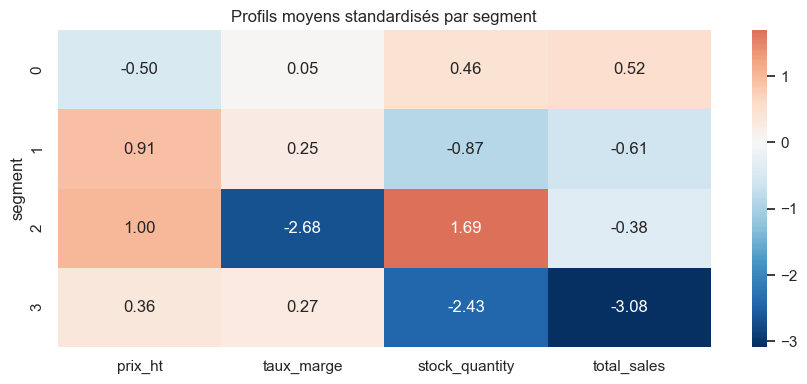

In [79]:
projection = pd.DataFrame(X_pca[:, :2], columns=['PC1', 'PC2'])
projection['segment'] = df['segment'].astype(str)
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=projection, x='PC1', y='PC2', hue='segment', palette='tab10', alpha=.7, ax=ax)
centers_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1], marker='X', s=180, c='black', label='Centroïdes')
ax.set(title='Références projetées sur les deux premiers axes ACP')
ax.legend(title='Segment'); plt.tight_layout(); plt.show()

profile = df.groupby('segment').agg(
    references=('product_id', 'size'), prix_median=('prix_ht', 'median'),
    marge_moyenne=('taux_marge', 'mean'), stock_median=('stock_quantity', 'median'),
    ventes_mediane=('total_sales', 'median'), ca_total=('ca_par_article', 'sum'),
    valorisation_stock=('valorisation_stock', 'sum')
).round(2)
display(profile)

profile_scaled = pd.DataFrame(X_scaled, columns=FEATURES).assign(segment=df['segment'].values).groupby('segment').mean()
plt.figure(figsize=(9, 4))
sns.heatmap(profile_scaled, annot=True, fmt='.2f', center=0, cmap='RdBu_r')
plt.title('Profils moyens standardisés par segment')
plt.tight_layout(); plt.show()

## 10. Traduction métier et actions proposées

Les identifiants numériques K-means sont arbitraires. Les noms ci-dessous reposent sur les profils observés ; ils sont à valider avec les achats et le commerce avant toute décision.

,segment,action_prioritaire
0,Cœur de catalogue actif,Sécuriser les réassorts et suivre les ruptures...
1,Premium à faible volume,Maintenir une disponibilité mesurée ; vérifier...
2,Surstock à surveiller,Geler ou réduire les réassorts ; analyser rota...
3,Références inactives à auditer,"Auditer la fiche produit et décider : relance,..."


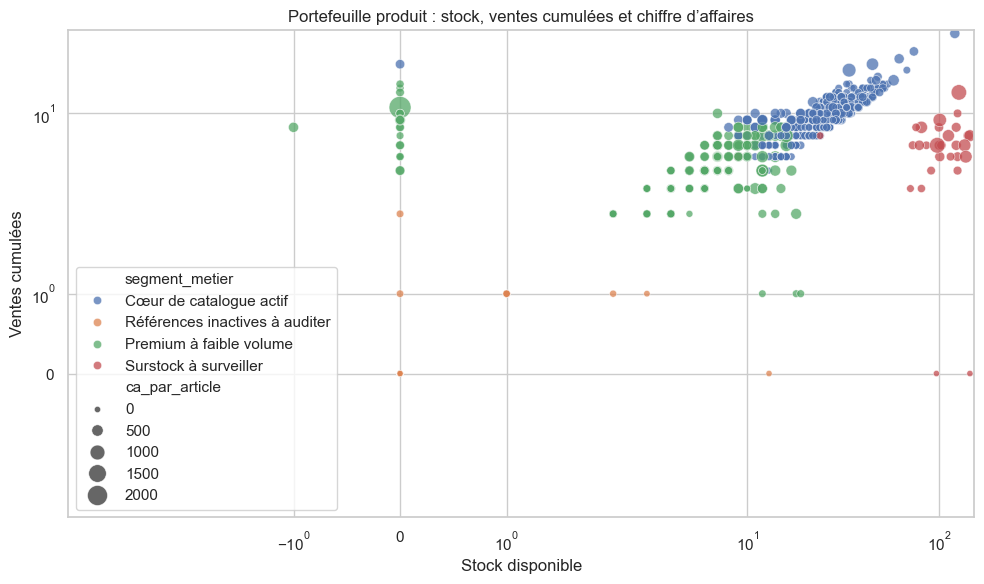

In [80]:
labels_metier = {
    0: 'Cœur de catalogue actif',
    1: 'Premium à faible volume',
    2: 'Surstock à surveiller',
    3: 'Références inactives à auditer',
}
df['segment_metier'] = df['segment'].map(labels_metier)
plan_action = pd.DataFrame({
    'segment': list(labels_metier.values()),
    'action_prioritaire': [
        'Sécuriser les réassorts et suivre les ruptures potentielles.',
        'Maintenir une disponibilité mesurée ; vérifier le positionnement et la marge.',
        'Geler ou réduire les réassorts ; analyser rotation, millésime et promotion.',
        'Auditer la fiche produit et décider : relance, retrait ou déstockage.'
    ]
})
display(plan_action)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='stock_quantity', y='total_sales', hue='segment_metier',
                size='ca_par_article', sizes=(20, 250), alpha=.75, ax=ax)
ax.set_xscale('symlog'); ax.set_yscale('symlog')
ax.set(title='Portefeuille produit : stock, ventes cumulées et chiffre d’affaires',
       xlabel='Stock disponible', ylabel='Ventes cumulées')
plt.tight_layout(); plt.show()

## Limites et conditions d'usage

- Les ventes sont cumulées et non datées : aucune saisonnalité, vitesse de rotation temporelle ou prévision ne peut être inférée.
- K-means privilégie des groupes compacts : c'est une aide au tri, pas une vérité métier.
- Les références à stock nul peuvent être épuisées, retirées ou non suivies ; elles exigent une vérification opérationnelle.
- La segmentation devra être recalculée avec un export récent et, idéalement, complétée par les lignes de commande datées pour construire ensuite un modèle de prévision fiable.